In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random

# Grafiklerin notebook içinde görünmesi için
%matplotlib inline

# Uyarıları kapatmak için
import warnings
warnings.filterwarnings('ignore')

In [34]:
dataset_path = "/home/ugo/Documents/Python/brain_tumor/Epic and CSCR hospital Dataset"

train_dir = "/home/ugo/Documents/Python/brain_tumor/Epic and CSCR hospital Dataset/Train"
test_dir = "/home/ugo/Documents/Python/brain_tumor/Epic and CSCR hospital Dataset/Test"

train_classes = sorted(os.listdir(train_dir))
test_classes = sorted(os.listdir(test_dir))

print("Sınıflar:", train_classes)


Sınıflar: ['glioma', 'meningioma', 'notumor', 'pituitary']


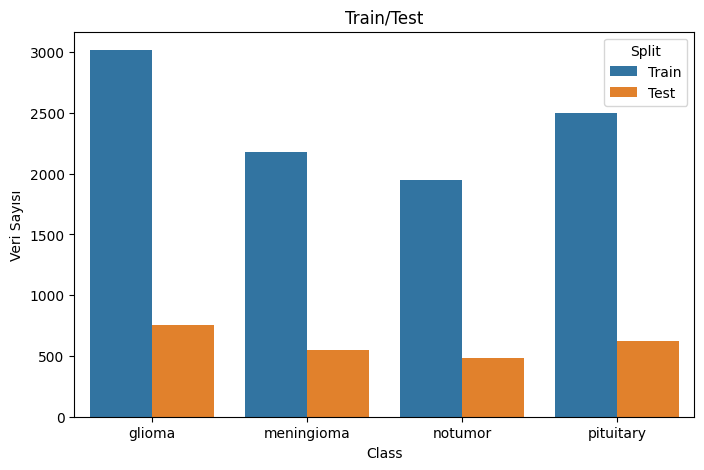

In [38]:
def class_dagilimi(base_dir, classes):
    data = []
    for classs in classes:
        cls_path = os.path.join(base_dir, classs)
        count = len(os.listdir(cls_path))
        data.append({'Split': os.path.basename(base_dir), 'Class': classs, 'Count': count})
    return data

train_dist = class_dagilimi(train_dir, train_classes)
test_dist = class_dagilimi(test_dir, test_classes)

df_dist = pd.DataFrame(train_dist + test_dist)

plt.figure(figsize=(8,5))
sns.barplot(data=df_dist, x='Class', y='Count', hue='Split')
plt.title('Train/Test')
plt.ylabel('Veri Sayısı')
plt.xlabel('Class')
plt.show()

## 4. Örnek Görüntülerin Görselleştirilmesi
Her bir sınıftan rastgele birkaç örnek görüntü matplotlib ile görselleştirilecektir.

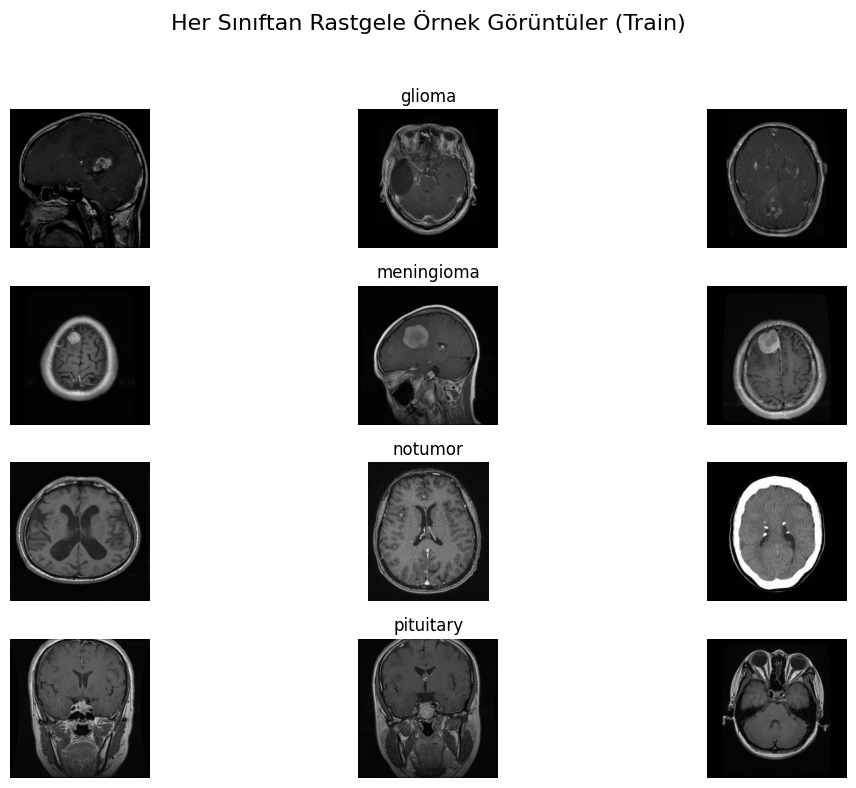

In [ ]:
ornek_sayisi = 3  

plt.figure(figsize=(12, 8))
for idx, cls in enumerate(train_classes):
    cls_path = os.path.join(train_dir, cls)
    images = os.listdir(cls_path)
    samples = random.sample(images, min(ornek_sayısı, len(images)))
    for j, img_name in enumerate(samples):
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path)
        plt.subplot(len(train_classes), ornek_sayısı, idx*ornek_sayısı + j + 1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        if j == 1:
            plt.title(cls)
plt.suptitle('Her Sınıftan Rastgele Örnek Görüntüler (Train)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 5. Görüntü Boyutlarının Analizi
Train ve Test klasörlerindeki görüntülerin boyutları (yükseklik, genişlik) analiz edilecek ve dağılımı histogram ile gösterilecektir.

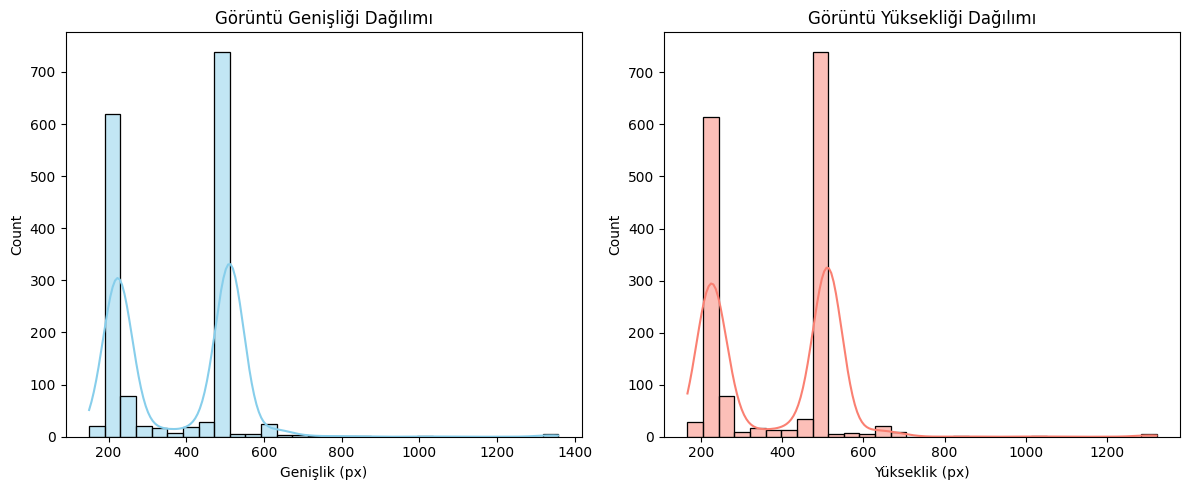

In [29]:
def get_image_shapes(base_dir, classes, max_images_per_class=200):
    shapes = []
    for cls in classes:
        cls_path = os.path.join(base_dir, cls)
        images = os.listdir(cls_path)
        for img_name in images[:max_images_per_class]:  # Çok büyük veri için sınır koyduk
            img_path = os.path.join(cls_path, img_name)
            try:
                with Image.open(img_path) as img:
                    shapes.append({'Split': os.path.basename(base_dir),
                                   'Class': cls,
                                   'Width': img.width,
                                   'Height': img.height})
            except Exception as e:
                continue
    return pd.DataFrame(shapes)

df_shapes_train = get_image_shapes(train_dir, train_classes)
df_shapes_test = get_image_shapes(test_dir, test_classes)
df_shapes = pd.concat([df_shapes_train, df_shapes_test], ignore_index=True)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_shapes['Width'], bins=30, kde=True, color='skyblue')
plt.title('Görüntü Genişliği Dağılımı')
plt.xlabel('Genişlik (px)')

plt.subplot(1,2,2)
sns.histplot(df_shapes['Height'], bins=30, kde=True, color='salmon')
plt.title('Görüntü Yüksekliği Dağılımı')
plt.xlabel('Yükseklik (px)')

plt.tight_layout()
plt.show()

## 6. Veri Setindeki Toplam Görüntü Sayısının Hesaplanması
Train ve Test klasörlerindeki toplam görüntü sayısı hesaplanacak ve tablo olarak gösterilecektir.

In [30]:
summary = []

for split_name, split_dir, classes in zip(['Train', 'Test'], [train_dir, test_dir], [train_classes, test_classes]):
    total = 0
    for cls in classes:
        cls_path = os.path.join(split_dir, cls)
        count = len(os.listdir(cls_path))
        summary.append({'Split': split_name, 'Class': cls, 'Count': count})
        total += count
    summary.append({'Split': split_name, 'Class': 'Toplam', 'Count': total})

df_summary = pd.DataFrame(summary)
display(df_summary.pivot(index='Class', columns='Split', values='Count').fillna(0).astype(int))

Split,Test,Train
Class,,
Toplam,2414,9650
glioma,755,3018
meningioma,546,2183
notumor,487,1945
pituitary,626,2504
